In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlss-sp-25-classification/sample_submission.csv
/kaggle/input/mlss-sp-25-classification/train.csv
/kaggle/input/mlss-sp-25-classification/test.csv


In [2]:

train = pd.read_csv('/kaggle/input/mlss-sp-25-classification/train.csv')
test = pd.read_csv('/kaggle/input/mlss-sp-25-classification/test.csv')
sample = pd.read_csv('/kaggle/input/mlss-sp-25-classification/sample_submission.csv')
ID = test['id']
train = train.drop(['id'], axis = 1)
test = test.drop(['id'], axis = 1)

In [3]:
train

,elevation,aspect,slope,horizontal_distance_to_hydrology,vertical_distance_to_hydrology,horizontal_distance_to_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,horizontal_distance_to_fire_points,...,soil_type32,soil_type33,soil_type34,soil_type35,soil_type36,soil_type37,soil_type38,soil_type39,soil_type40,cover_type
0,2840,20,6,42,6,566,216,228,149,566,...,0,0,0,0,0,0,0,0,0,2
1,2690,95,11,0,0,1605,238,223,114,2346,...,0,0,0,0,0,0,0,0,0,2
2,2759,22,17,0,0,752,207,200,126,2082,...,0,0,0,0,0,0,0,0,0,1
3,3140,51,27,400,219,1981,222,172,68,2754,...,0,1,0,0,0,0,0,0,0,1
4,3170,29,6,30,1,1288,218,226,144,1205,...,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,2703,150,8,256,30,1560,230,240,142,787,...,0,0,0,0,0,0,0,0,0,2
199996,2797,69,12,402,1,1798,233,215,113,2758,...,0,0,0,0,0,0,0,0,0,2
199997,2940,249,19,255,104,900,175,250,210,685,...,0,0,0,0,0,0,0,0,0,2
199998,2919,103,9,234,40,3303,235,229,125,2387,...,0,0,0,0,0,0,0,0,0,2


In [4]:
test

,elevation,aspect,slope,horizontal_distance_to_hydrology,vertical_distance_to_hydrology,horizontal_distance_to_roadways,hillshade_9am,hillshade_noon,hillshade_3pm,horizontal_distance_to_fire_points,...,soil_type31,soil_type32,soil_type33,soil_type34,soil_type35,soil_type36,soil_type37,soil_type38,soil_type39,soil_type40
0,3089,355,5,630,88,2144,211,230,157,2547,...,0,1,0,0,0,0,0,0,0,0
1,3165,56,10,510,-29,797,227,218,124,1341,...,0,0,0,0,0,0,0,0,0,0
2,3142,23,8,633,125,1674,216,223,144,2608,...,1,0,0,0,0,0,0,0,0,0
3,2782,330,23,85,7,1368,158,204,182,1565,...,0,0,0,0,0,0,0,0,0,0
4,2775,36,14,150,24,1316,218,208,123,2255,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,2984,82,21,95,18,5152,243,199,77,604,...,0,0,0,0,0,0,0,0,0,0
199996,3208,281,19,582,67,240,165,238,211,2207,...,0,0,1,0,0,0,0,0,0,0
199997,2973,20,13,685,154,1290,210,211,135,2591,...,0,0,1,0,0,0,0,0,0,0
199998,3198,266,12,95,14,3000,189,245,196,525,...,0,1,0,0,0,0,0,0,0,0


In [5]:
train.isnull().sum()

elevation                             0
aspect                                0
slope                                 0
horizontal_distance_to_hydrology      0
vertical_distance_to_hydrology        0
horizontal_distance_to_roadways       0
hillshade_9am                         0
hillshade_noon                        0
hillshade_3pm                         0
horizontal_distance_to_fire_points    0
wilderness_area1                      0
wilderness_area2                      0
wilderness_area3                      0
wilderness_area4                      0
soil_type1                            0
soil_type2                            0
soil_type3                            0
soil_type4                            0
soil_type5                            0
soil_type6                            0
soil_type7                            0
soil_type8                            0
soil_type9                            0
soil_type10                           0
soil_type11                           0


In [6]:
test.isnull().sum()

elevation                             0
aspect                                0
slope                                 0
horizontal_distance_to_hydrology      0
vertical_distance_to_hydrology        0
horizontal_distance_to_roadways       0
hillshade_9am                         0
hillshade_noon                        0
hillshade_3pm                         0
horizontal_distance_to_fire_points    0
wilderness_area1                      0
wilderness_area2                      0
wilderness_area3                      0
wilderness_area4                      0
soil_type1                            0
soil_type2                            0
soil_type3                            0
soil_type4                            0
soil_type5                            0
soil_type6                            0
soil_type7                            0
soil_type8                            0
soil_type9                            0
soil_type10                           0
soil_type11                           0


In [7]:
X_train = train.drop(['cover_type'], axis = 1)
y_train = train['cover_type']
X_test = test

In [8]:
std_vars = ['slope', 'horizontal_distance_to_hydrology', 'vertical_distance_to_hydrology', 
    'horizontal_distance_to_roadways','horizontal_distance_to_fire_points']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[std_vars] = scaler.fit_transform(X_train[std_vars])
test[std_vars] = scaler.transform(test[std_vars])

In [9]:
min_max_vars = ['aspect', 'hillshade_9am', 'hillshade_noon', 
    'hillshade_3pm']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train[min_max_vars] = scaler.fit_transform(X_train[min_max_vars])
test[min_max_vars] = scaler.transform(test[min_max_vars])

In [10]:
from sklearn.preprocessing import RobustScaler
robust_scaler = RobustScaler()
X_train['elevation'] = robust_scaler.fit_transform(X_train[['elevation']])
test['elevation'] = robust_scaler.transform(test[['elevation']])

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

models = {
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "Naïve Bayes": GaussianNB()
}

In [12]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model_performance = {}

In [13]:
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='f1_macro')
    model_performance[name] = scores.mean()
    print(f"{name} - Mean Accuracy: {scores.mean():.4f}")

LDA - Mean Accuracy: 0.5086


/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


QDA - Mean Accuracy: 0.1340
Naïve Bayes - Mean Accuracy: 0.1452


In [14]:
# best model
best_model_name = max(model_performance, key=model_performance.get)
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name}")


Best Model: LDA


In [15]:
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

In [16]:
sample

,id,cover_type
0,A200001,4
1,A200002,6
2,A200003,6
3,A200004,3
4,A200005,1
...,...,...
199995,A399996,2
199996,A399997,4
199997,A399998,1
199998,A399999,5


In [17]:
submission = pd.DataFrame({"id": ID, "cover_type": pred})

In [18]:
submission

,id,cover_type
0,A200001,2
1,A200002,1
2,A200003,1
3,A200004,2
4,A200005,2
...,...,...
199995,A399996,2
199996,A399997,1
199997,A399998,2
199998,A399999,1


In [19]:
submission.to_csv("submission.csv", index=False)

In [20]:
train.columns

Index(['elevation', 'aspect', 'slope', 'horizontal_distance_to_hydrology',
       'vertical_distance_to_hydrology', 'horizontal_distance_to_roadways',
       'hillshade_9am', 'hillshade_noon', 'hillshade_3pm',
       'horizontal_distance_to_fire_points', 'wilderness_area1',
       'wilderness_area2', 'wilderness_area3', 'wilderness_area4',
       'soil_type1', 'soil_type2', 'soil_type3', 'soil_type4', 'soil_type5',
       'soil_type6', 'soil_type7', 'soil_type8', 'soil_type9', 'soil_type10',
       'soil_type11', 'soil_type12', 'soil_type13', 'soil_type14',
       'soil_type15', 'soil_type16', 'soil_type17', 'soil_type18',
       'soil_type19', 'soil_type20', 'soil_type21', 'soil_type22',
       'soil_type23', 'soil_type24', 'soil_type25', 'soil_type26',
       'soil_type27', 'soil_type28', 'soil_type29', 'soil_type30',
       'soil_type31', 'soil_type32', 'soil_type33', 'soil_type34',
       'soil_type35', 'soil_type36', 'soil_type37', 'soil_type38',
       'soil_type39', 'soil_type40

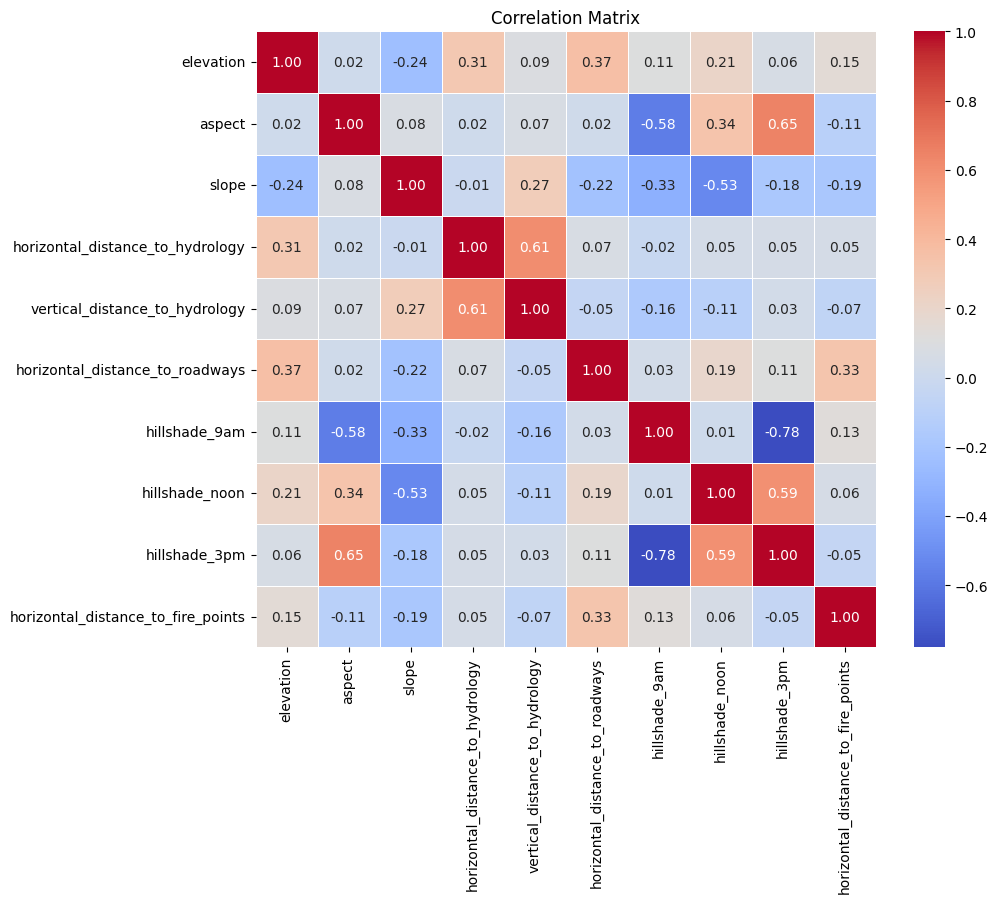

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

temp = ['wilderness_area1',
       'wilderness_area2', 'wilderness_area3', 'wilderness_area4',
        'soil_type1', 'soil_type2', 'soil_type3', 'soil_type4', 'soil_type5',
       'soil_type6', 'soil_type7', 'soil_type8', 'soil_type9', 'soil_type10',
       'soil_type11', 'soil_type12', 'soil_type13', 'soil_type14',
       'soil_type15', 'soil_type16', 'soil_type17', 'soil_type18',
       'soil_type19', 'soil_type20', 'soil_type21', 'soil_type22',
       'soil_type23', 'soil_type24', 'soil_type25', 'soil_type26',
       'soil_type27', 'soil_type28', 'soil_type29', 'soil_type30',
       'soil_type31', 'soil_type32', 'soil_type33', 'soil_type34',
       'soil_type35', 'soil_type36', 'soil_type37', 'soil_type38',
       'soil_type39', 'soil_type40', 'cover_type']
df = train.drop(temp, axis = 1)

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()